# Supporting Plots to help Contextualise this Research

In [64]:
import sys
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

ROOT = "/vol/biomedic3/bglocker/mscproj/zm1224/msc_individual_project/"
sys.path.append(ROOT)

In [ ]:
def display_sample_images(sample_df, dataset_path, dataset_name, image_column):
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    for i, (index, row) in enumerate(sample_df.iterrows()):
        img_path = os.path.join(dataset_path, row[image_column])
        img = Image.open(img_path)
        axes[i].imshow(img, cmap="gray", aspect="equal")

        axes[i].axis('off')
        axes[i].set_xticks([])
        axes[i].set_yticks([])
        axes[i].spines[:].set_visible(False)
        axes[i].set_title(row[image_column], fontsize=8)

    plt.suptitle(f"Sample Images from {dataset_name}", fontsize=16)
    plt.subplots_adjust(wspace=0.1, hspace=0.05)
    plt.tight_layout()
    plt.show()
    plt.savefig(f"{dataset_name}_examples.png", dpi=300, bbox_inches="tight")

In [ ]:
from PIL import Image, ImageOps
import numpy as np
import os
import matplotlib.pyplot as plt

def display_sample_images(sample_df, dataset_path, dataset_name, image_column):
    # Load up to 6 images first
    items = []
    for _, row in sample_df.iloc[:6].iterrows():
        p = os.path.join(dataset_path, row[image_column])
        im = Image.open(p)
        items.append((p, im))

    # Choose a common canvas size
    sizes = [im.size for _, im in items] # (W, H)
    max_w = max(w for w, _ in sizes)
    max_h = max(h for _, h in sizes)

    fig, axes = plt.subplots(2, 3, figsize=(15, 10), constrained_layout=True)
    axes = axes.flatten()

    for i, (p, im) in enumerate(items):
        if i >= len(axes): break
        # LPad to the same size without distorting
        padded = ImageOps.pad(im, (max_w, max_h), color=0, centering=(0.5, 0.5))
        axes[i].imshow(padded, cmap="gray")
        axes[i].axis("off")
        axes[i].set_title(os.path.basename(p), fontsize=8)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    fig.suptitle(f"Sample Images from {dataset_name}", fontsize=16)
    fig.savefig(f"{dataset_name}_examples.png", dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()


### PadChest

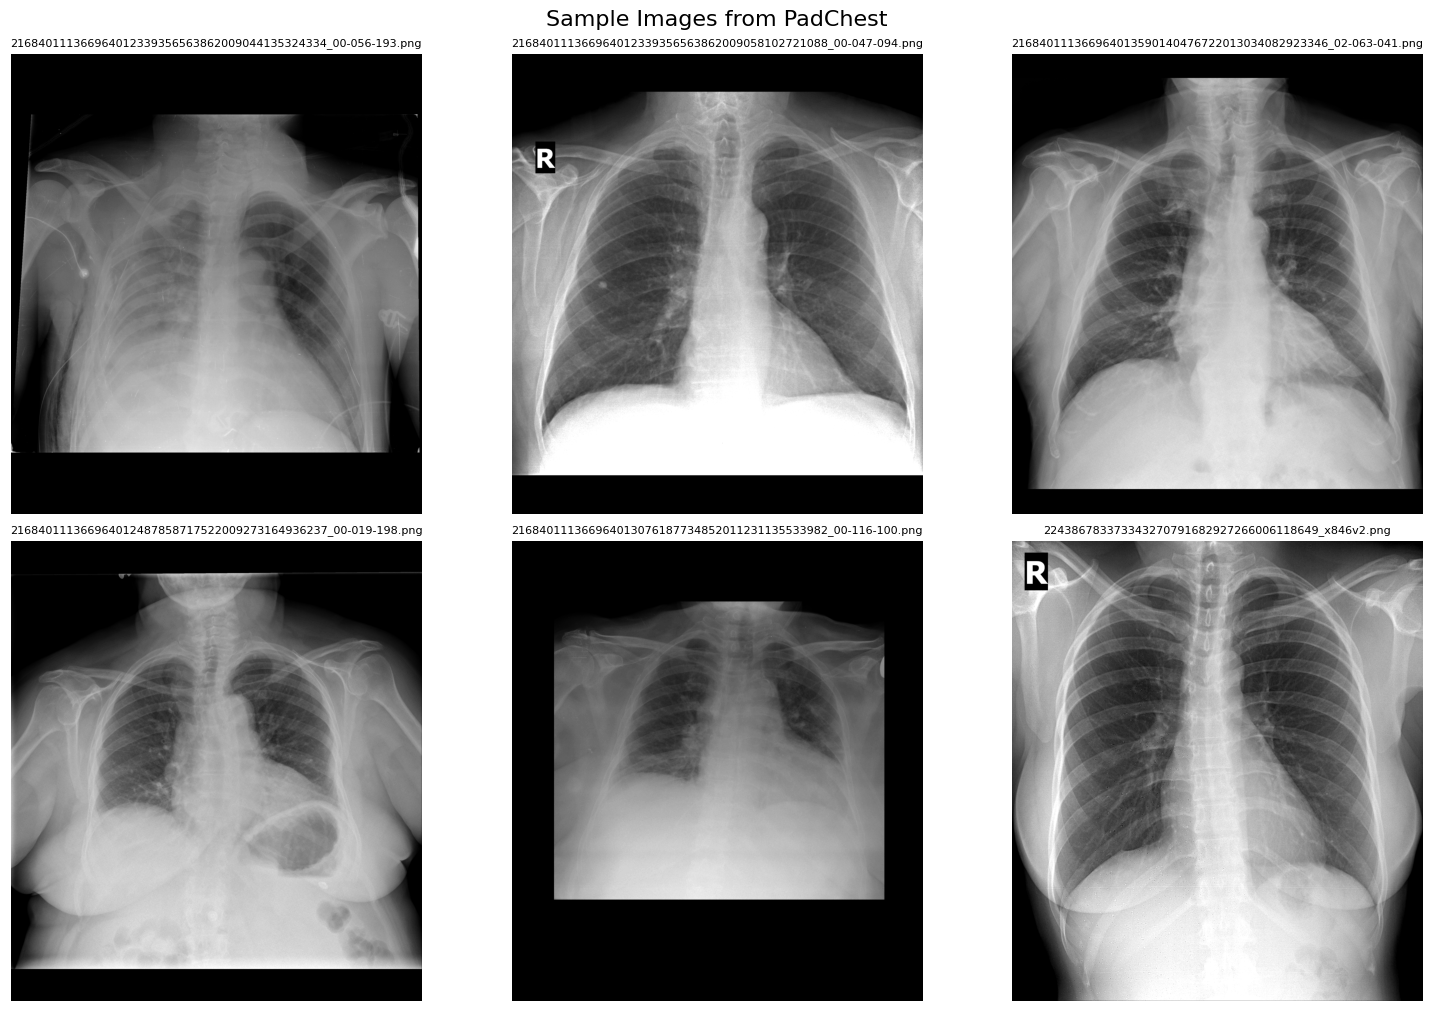

In [83]:
from default_paths import PADCHEST_ROOT

df = pd.read_csv(PADCHEST_ROOT / "PADCHEST_chest_x_ray_images_labels_160K_01.02.19.csv")
sample_df = df.sample(n=6)

display_sample_images(sample_df, PADCHEST_ROOT / "images", "PadChest", "ImageID")

### Mammography

480323
480323


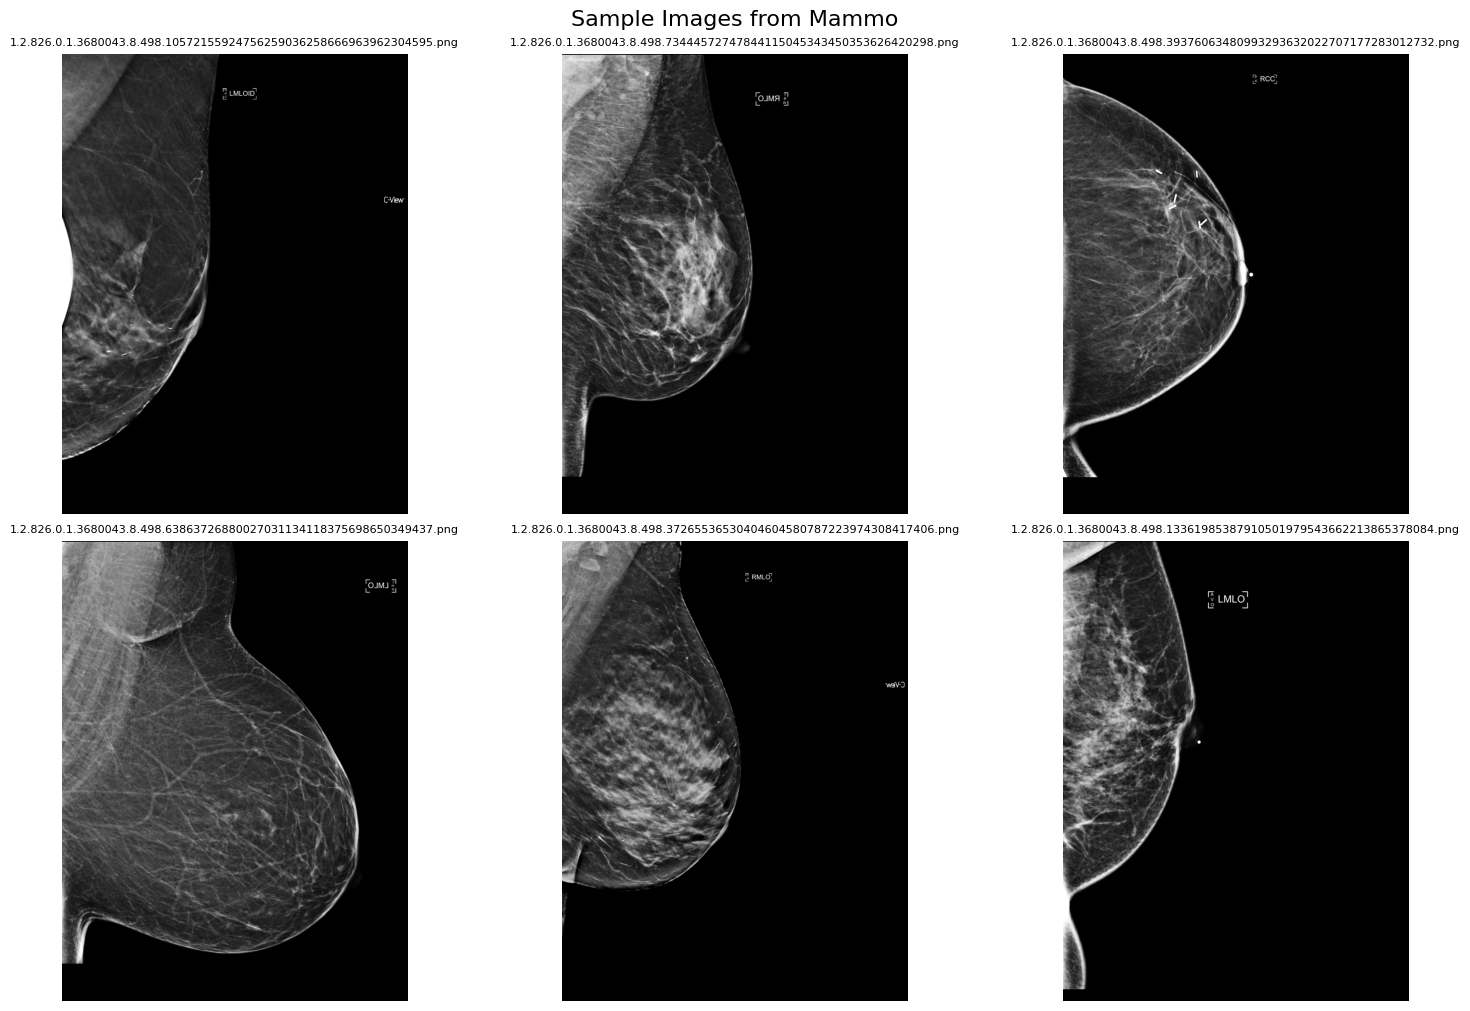

In [84]:
from default_paths import EMBED_ROOT

full_dicom = pd.read_csv(
    EMBED_ROOT / "tables/EMBED_OpenData_metadata.csv", low_memory=False
)[
    [
        "InstanceNumber",
        "anon_dicom_path",
        "PixelSpacing",
        "ImagerPixelSpacing",
        "Rows",
        "Columns",
    ]
]

dicom = pd.read_csv(
    EMBED_ROOT / "tables/EMBED_OpenData_metadata_reduced.csv", low_memory=False
)
print(len(dicom))
dicom = dicom.merge(full_dicom, on="anon_dicom_path")
print(len(dicom))
dicom["image_path"] = (
    dicom["empi_anon"].astype("str")
    + "/"
    + dicom["anon_dicom_path"].str.split("/").str[-1].str.split(".dcm").str[0]
    + ".png"
)

sample_df = dicom.sample(n=6)

display_sample_images(sample_df, EMBED_ROOT / "images/png/1024x768", "Mammo", "image_path")

### Retina

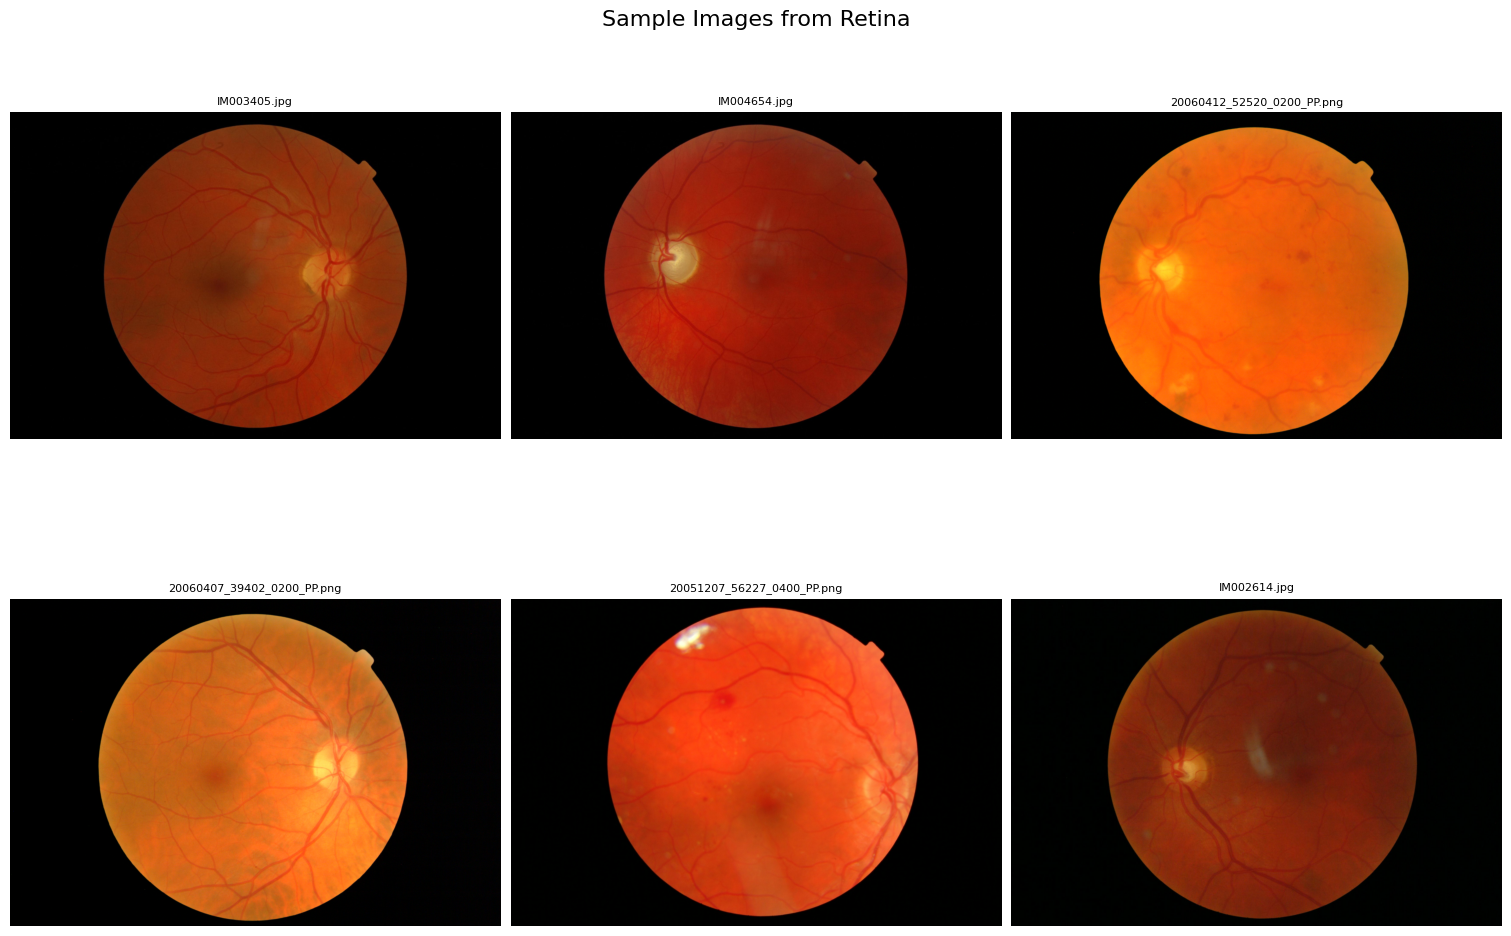

In [85]:
from  default_paths import MESSIDOR_ROOT

df = pd.read_csv(MESSIDOR_ROOT / "messidor_data.csv")
sample_df = df.sample(n=6)

display_sample_images(sample_df, MESSIDOR_ROOT / "IMAGES", "Retina", "image_id")

### RSNA

NotADirectoryError: [Errno 20] Not a directory: '/vol/biomedic3/bglocker/mscproj/zm1224/msc_individual_project/experiments/train_rsna.csv/images/00004682_009.png'

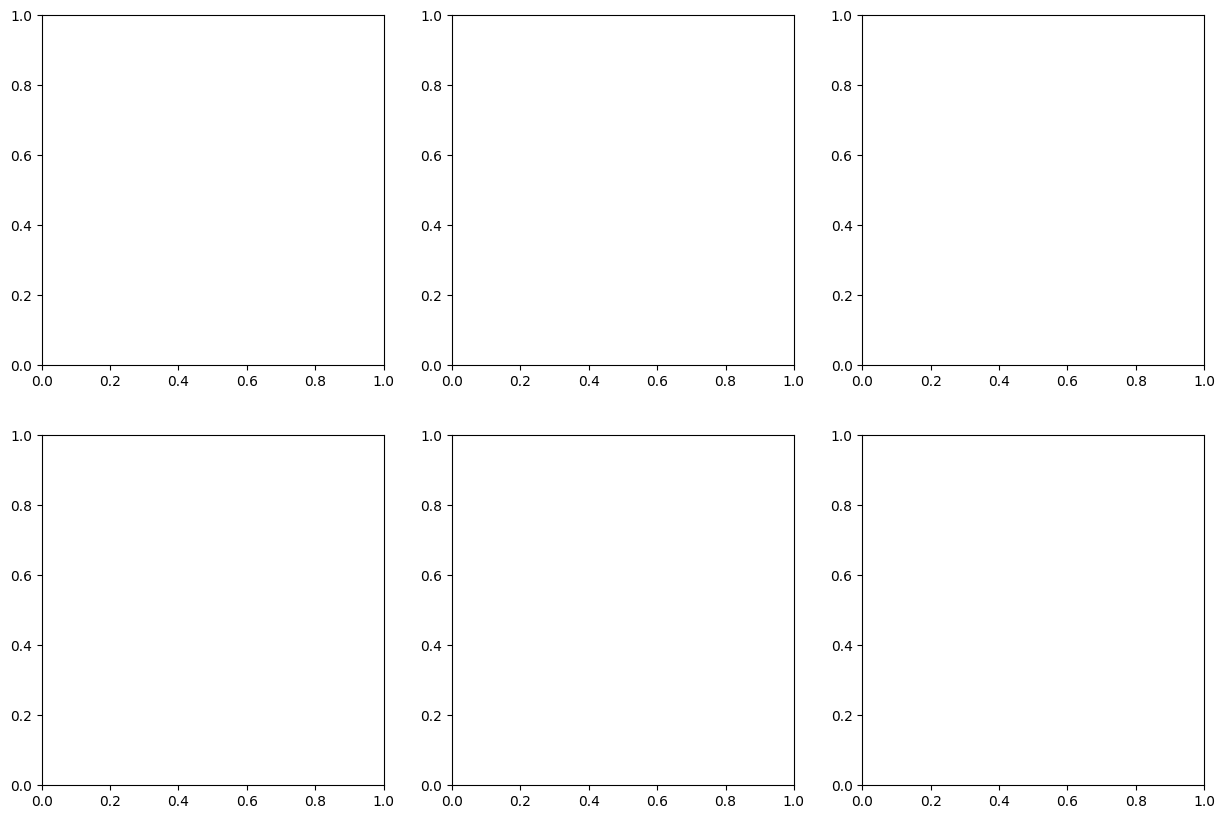

In [69]:
RSNA_PATH = Path(ROOT) / "experiments" / "train_rsna.csv"

df = pd.read_csv(RSNA_PATH)
sample_df = df.sample(n=6)

display_sample_images(sample_df, RSNA_PATH / "images", "Pneumonia", "nih_image_id")